Group #1

Harry Lazaridis, <harrylaz@kth.se>

San Kaneskan, <sanmo@kth.se>

# Summary of the results and findings

# Description of the methodology

The tasks for this lab was modelled by using 5 different dices that has 4, 6, 8, 12 and 20 sides each. For each of the dices the outcomes from the integers were given 1 to **n** and the outcome had the probability of 1/**n** where **n** = the sided dice.
The total sum for the dices could amount up to 50 and the smallest could end up as 5. For the trials it would be counted as a win where **S** (total amount of the thrown dice), **10 >= S** or  **S>= 45**.

## Task 1 and 2
Tasks 1 and 2 were done using discrete convolution to calculate the probability distribution of **S**, which is the sum of all five dice. The probability function of each dice was first represented by an array containing **n** values equal to 1/**n**. The probability of each possible sum was then found by multiplying the probabilities of all pairs of outcomes that produced that sum and adding the results together.

## Task 3

Task 3 was done using a Monte Carlo simulation to estimate the probability of winning. During each trial, all five dice were simulated by generating a random integer from 1 to **n**, including both limits, for each die. The results from the five dice were then added together to calculate **S**.

If **S ≤ 10** or **S ≥ 45**, the trial was counted as a win. This process was repeated 1,000 times, and the simulated probability was calculated by dividing the number of winning trials by the total number of trials.

## Task 4

For Task 4, the Monte Carlo simulation was performed using different numbers of trials, starting from 10 and increasing up to 100,000. The simulated probability of winning was calculated once for each number of trials and the results were stored in a table.

The results were then displayed in a figure to show how the simulated probability changed as the number of trials increased. A logarithmic scale was used for the number of trials because the tested values covered a large range. The exact probability from Task 2 was added as a horizontal line, which made it possible to compare the simulated results with the exact result.


# Mathematical formulas and equations
Relevant formulas and equations

***Task 2***

P(Win) = P(S <= 10) + P(S >= 45)

***Task 3***

P(simulation) = (Number of Wins) / (Number of Trials)

***Task 5***


# Numerical results

***Task 1***
Table

***Task 2***


***Task 3***


***Task 4***


***Task 5***

# Analysis and discussion

# Code 

## Imports

In [9]:
import numpy as np
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt

## Task 1 & 2 - Discrete convolution



In [10]:
faces = np.array([4, 6, 8, 12, 20])

def p(n):
    return np.ones(n) / n

pf = p(faces[0])
for n in faces[1:]:
    pf = np.convolve(pf, p(n))

s_values = np.arange(5, 5 + len(pf))

In [11]:
table = pd.DataFrame({"s": s_values, "P(S = s)": pf})
table

,s,P(S = s)
0,5,0.000022
1,6,0.000109
2,7,0.000326
3,8,0.000760
4,9,0.001497
5,10,0.002626
6,11,0.004210
7,12,0.006293
8,13,0.008876
9,14,0.011914


In [12]:
p_low = pf[(s_values <= 10)].sum()
p_high = pf[(s_values >= 45)].sum()
p_win = p_low + p_high

print(f"P(S <= 10) = {p_low:.5f}")
print(f"P(S >= 45) = {p_high:.5f}")
print(f"P(Win) = {p_win:.5f}")

P(S <= 10) = 0.00534
P(S >= 45) = 0.00534
P(Win) = 0.01068


## Task 3, 4 & 5

In [13]:
def simulation_probability_of_win(n_trials):
    win = 0
    for _ in range(n_trials):
        S = 0 
        for n in faces:
            S += random.randint(1, n + 1) 
        if S <= 10 or S >= 45:
            win += 1
    return win / n_trials

p_win_1000 = simulation_probability_of_win(1000)

print(f"Monte Carlo simulation with 1000 trials: {p_win_1000:.5f}")
print(f"Discrete convolultion: {p_win:.5f}")


Monte Carlo simulation with 1000 trials: 0.01400
Discrete convolultion: 0.01068


In [14]:
trials_amount = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

sim = [simulation_probability_of_win(n) for n in trials_amount]

results = pd.DataFrame({
    "number_of_trials": trials_amount,
    "results": sim
})

results


,number_of_trials,results
0,10,0.00000
1,50,0.00000
2,100,0.01000
3,500,0.02000
4,1000,0.01100
5,5000,0.01080
6,10000,0.01020
7,50000,0.01016
8,100000,0.01046


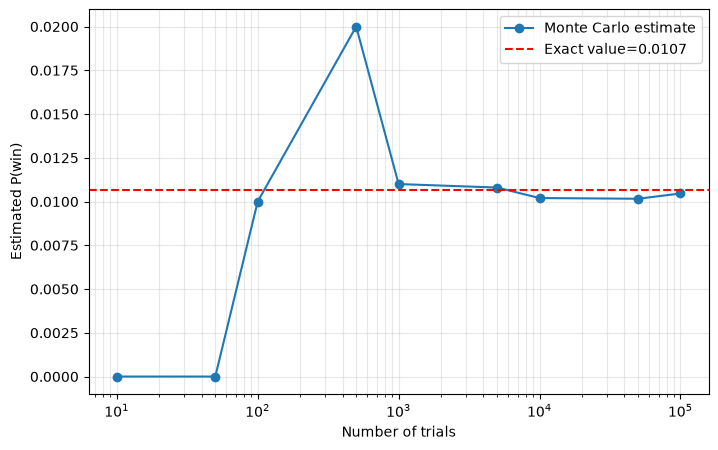

In [15]:
plt.figure(figsize=(8, 5))
plt.semilogx(trials_amount, sim, "o-", label="Monte Carlo estimate")
plt.axhline(p_win, color="red", linestyle="--", label=f"Exact value={p_win:.4f}")
plt.xlabel("Number of trials")
plt.ylabel("Estimated P(win)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

In [16]:
#task 5
#how often the relative error is below 10%
def successes(n, reps=50):
    success = 0
    for _ in range(reps):
        P = simulation_probability_of_win(n)
        relative_error = abs(P - p_win) / p_win
        if relative_error < 0.10:
            success += 1
    return success / reps


#different numbers of trials
test_trials = [1000, 5000, 10000, 20000, 40000, 60000, 100000]

success_rates = [successes(n) for n in test_trials]


# Display the results
task5_results = pd.DataFrame({
    "Number of trials": test_trials,
    "Proportion below 10% error": success_rates
})

print(task5_results.to_string(index=False))

 Number of trials  Proportion below 10% error
             1000                        0.14
             5000                        0.52
            10000                        0.72
            20000                        0.86
            40000                        0.96
            60000                        0.98
           100000                        1.00
